In [2]:
#Cleaning data prior to assigning polarity & subjectivity
import pandas as pd
import numpy as np
import os
from matplotlib import pyplot as plt
from pathlib import Path
from textblob import TextBlob

data_dir = os.path.join(Path(os.getcwd()).parent.parent, '.data')

# Get Comment Data
pdf_comments = pd.read_csv(os.path.join(data_dir, 'Forum comment ferpa.csv'))

#Remove columns irrelevant to polarity & subjectivity
del pdf_comments['anonymous']
del pdf_comments['anonymous_to_peers']
del pdf_comments['upvotes']
del pdf_comments['downvotes']
del pdf_comments['abuse_flagger_count']
del pdf_comments['historical_abuse_flagger_count']
del pdf_comments['endorsed']
del pdf_comments['endorser_id']
del pdf_comments['endorsement_time']

pdf_comments


,id,thread_id,parent_id,user_id,course_id,body,updated_at,created_at
0,\x35633165393062633336313031333039623030303363...,\x35623765633435303362306162633039646330303161...,\x35623766323432316333303561643061333130303164...,1653997,course-v1:GTx+CS1301xII+1T2018,Enter your answer without spaces! I was going ...,12/22/18 19:30,12/22/18 19:30
1,\x35626565353734343336313031333039626330303137...,\x35626565353731336566356233333039626630303161...,NaN,1653997,course-v1:GTx+CS1301xII+1T2018,SmartBook that is :),11/16/18 5:36,11/16/18 5:36
2,\x35626164353931333362306162633039626530303364...,\x35623537383463353362306162633039623830303033...,\x35623661643566336333303561643061303930303065...,19528826,course-v1:GTx+CS1301xII+1T2018,What is the answer for this question? I tried ...,9/27/18 22:26,9/27/18 22:26
3,\x35623765323431393362306162633039396430303162...,\x35623632356432616333303561643039656330303039...,\x35623632383239323362306162633039393130303039...,577988,course-v1:GTx+CS1301xII+1T2018,Passed with output printed: 12 On the bubble ...,8/23/18 3:03,8/23/18 3:03
4,\x35623762626238383362306162633039393130303138...,\x35623537383463353362306162633039623830303033...,\x35623661643566336333303561643061303930303065...,11467721,course-v1:GTx+CS1301xII+1T2018,"I had the same problem with this question, I w...",8/21/18 7:13,8/21/18 7:13
...,...,...,...,...,...,...,...,...
9183,\x35616239396165363933373934303039653530303265...,\x35616238666430313933373934303039643830303264...,NaN,14334853,course-v1:GTx+MGT6203x+2T2018,I had RStudio crashing (every time) when estim...,3/29/18 3:17,3/27/18 1:14
9184,\x35616139636332383834343532613038346530303236...,\x35616139613161373234343531613039626530303235...,\x35616139633862353834343532613038343230303235...,14334853,course-v1:GTx+MGT6203x+2T2018,I could only get the accurate numbers when usi...,3/15/18 1:28,3/15/18 1:28
9185,\x35613832383262663834343532613038343830303065...,\x35613831616331623834343532613038363030303064...,\x35613831623261373834343532613038316230303064...,1999515,course-v1:GTx+MGT6203x+2T2018,I have the same issue here. Thanks for pointin...,2/13/18 6:16,2/13/18 6:16
9186,\x35396230633261623465643734393039653830303034...,\x35393962323436636134343230373061333730303034...,NaN,15576957,course-v1:GTx+CS6400x+2T2017,The exams are not available yet.,9/7/17 3:53,9/7/17 3:53


In [1]:
#Use matplotlib to create a histogram for polarity scores
import pandas as pd
import numpy as np
import os
from matplotlib import pyplot as plt
from pathlib import Path
from textblob import TextBlob

#create columns for polarity and subjectivity
pdf_comments['polarity'] = np.nan
pdf_comments['subjectivity'] = np.nan

#do sentiment analysis on each sentence and record its polarity and subjectiviy
for i in range(pdf_comments.body.size):
    wiki = TextBlob(pdf_comments.body[i])
    pdf_comments['polarity'][i] = wiki.sentiment.polarity
    pdf_comments['subjectivity'][i] = wiki.sentiment.subjectivity

#create histogram for polarities
polarities = []
for i in range(pdf_comments.body.size):
    polarities.append(pdf_comments['polarity'][i])
plt.hist(polarities)
plt.xlabel('Polarity Score')
plt.ylabel('Quantity')
plt.title('Histogram of Polarity Scores')
plt.grid(axis = 'y', alpha = 0.75)

pdf_comments

NameError: name 'pdf_comments' is not defined

<ipython-input-16-41bda6476292>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdf_comments['polarity'][i] = wiki.sentiment.polarity
<ipython-input-16-41bda6476292>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdf_comments['subjectivity'][i] = wiki.sentiment.subjectivity


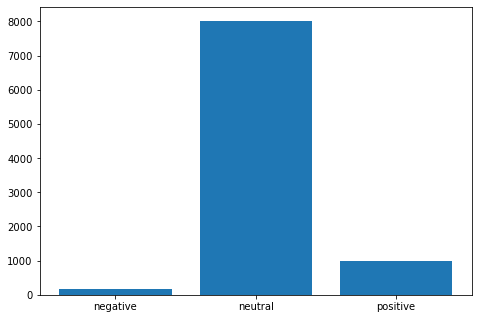

In [16]:
#Use matplotlib to create bar graph for number of positive, negative, neutral threads based on polarity scores
#create columns for polarity and subjectivity
pdf_comments['polarity'] = np.nan
pdf_comments['subjectivity'] = np.nan

#do sentiment analysis on each sentence and record its polarity and subjectiviy
for i in range(pdf_comments.body.size):
    wiki = TextBlob(pdf_comments.body[i])
    pdf_comments['polarity'][i] = wiki.sentiment.polarity
    pdf_comments['subjectivity'][i] = wiki.sentiment.subjectivity

#organize polarities into 3 categories: positive, negative, and neutral
positive = 0
negative = 0
neutral = 0
for i in range(pdf_comments.body.size):
    if pdf_comments['polarity'][i] > .4:
        positive += 1
    elif pdf_comments['polarity'][i] < -.4:
        negative += 1
    else:
        neutral += 1

        
#create bar chart showing number of threads in each category
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ranges = ['negative', 'neutral', 'positive']
count = [negative, neutral,positive]
ax.bar(ranges, count)
plt.show()



In [2]:
#Use Bokeh to create a more interactive histogram
import pandas as pd
import os
import numpy as np
from pathlib import Path
from bokeh.plotting import figure
from bokeh.io import output_notebook, show, output_file
from bokeh.models import ColumnDataSource, HoverTool, Panel
from bokeh.models.widgets import Tabs
from textblob import TextBlob
from bokeh.models import ColumnDataSource

data_dir = os.path.join(Path(os.getcwd()).parent.parent, '.data')

# Get Comment Data
pdf_comments = pd.read_csv(os.path.join(data_dir, 'Forum comment ferpa.csv'))

#create columns for polarity and subjectivity
pdf_comments['polarity'] = np.nan
pdf_comments['subjectivity'] = np.nan

#do sentiment analysis on each sentence and record its polarity and subjectiviy
for i in range(pdf_comments.body.size):
    wiki = TextBlob(pdf_comments.body[i])
    pdf_comments['polarity'][i] = wiki.sentiment.polarity
    pdf_comments['subjectivity'][i] = wiki.sentiment.subjectivity

#create histogram for polarities
arr_hist, edges = np.histogram(pdf_comments['polarity'], bins = int(2/.2), range = [-1, 1])
polarity = pd.DataFrame({'polarity': arr_hist, 
                       'left': edges[:-1], 
                       'right': edges[1:]})

#add column in histogram DataFrame for sentiment
sentiment = []
for left in polarity['left']:
    if left >= 0.4:
        sentiment.append("Positive")
    elif left <= -0.4:
        sentiment.append("Negative")
    else:
        sentiment.append("Neutral")
polarity['Sentiment'] = sentiment

                         
src = ColumnDataSource(polarity)

#create empty bokeh plot
p = figure(plot_height = 600, plot_width = 600, 
           title = 'Histogram of Polarity Scores',
          x_axis_label = 'Polarity Score', 
           y_axis_label = 'Number of Threads')

#fill plot with histogram data
p.quad(bottom=0, top='polarity', 
       left='left', right='right', source = src, 
       fill_color='blue', line_color='black',hover_fill_alpha = 1.0, hover_fill_color = 'yellow')


#add interactive element 
hover = HoverTool(tooltips = [('Sentiment', '@Sentiment'), ('Count', '@polarity')])
p.add_tools(hover)


show(p)

<ipython-input-2-8ee2aded0aac>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdf_comments['polarity'][i] = wiki.sentiment.polarity
<ipython-input-2-8ee2aded0aac>:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdf_comments['subjectivity'][i] = wiki.sentiment.subjectivity
